# LiDAR PCD with Intensity Exploration
This notebook reads a Point Cloud Data (PCD) file that includes **intensity** data, explores its structure, performs preprocessing, and visualizes the point cloud with intensity mapped to colors.

In [1]:
import os
import sys
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("Open3D:", o3d.__version__)
print("Numpy:", np.__version__)

Python: 3.11.14 | packaged by conda-forge | (main, Oct 13 2025, 14:29:50) [Clang 19.1.7 ]
Open3D: 0.19.0
Numpy: 2.4.6


## Loading the PCD File with Intensity
We will use Open3D's Tensor API to correctly load the point cloud, as it natively handles custom attributes like `intensity` and double-precision coordinates without data loss.

In [2]:
PCD_FILE = "lidar_with_intensity/frame_00008.pcd"

if not os.path.exists(PCD_FILE):
    print(f"Error: File {PCD_FILE} not found.")
else:
    # Use the Tensor API to read the point cloud, which handles custom fields like 'intensity'
    t_pcd = o3d.t.io.read_point_cloud(PCD_FILE)
    
    print("Loaded point cloud tensor:")
    print(t_pcd)
    
    # Check if 'intensity' is available
    if 'intensity' in t_pcd.point:
        print("\nIntensity field found in the point cloud!")
    else:
        print("\nWarning: No intensity field found in the PCD file. Check the file format.")


Loaded point cloud tensor:
PointCloud on CPU:0 [227351 points (Float32)].
Attributes: intensity (dtype = Float32, shape = {227351, 1}).

Intensity field found in the point cloud!


## Preprocessing Data
We need to remove `NaN` and `Inf` points, which are common in MATLAB-generated organized point clouds.
Then, we extract the coordinates and intensity values as NumPy arrays.

In [3]:
# Extract valid points mask (where coordinates are finite)
points = t_pcd.point.positions.numpy()
valid_mask = np.isfinite(points).all(axis=1)

# Apply mask to coordinates
valid_points = points[valid_mask]
print(f"Total points before filtering: {len(points)}")
print(f"Valid points after filtering: {len(valid_points)}")

# Extract intensity and apply mask
if 'intensity' in t_pcd.point:
    intensities = t_pcd.point.intensity.numpy()[valid_mask].flatten()
    print(f"Intensity range: Min={intensities.min():.2f}, Max={intensities.max():.2f}")
else:
    intensities = np.zeros(len(valid_points))


Total points before filtering: 227351
Valid points after filtering: 52878
Intensity range: Min=3.00, Max=255.00


## Downsampling for Visualization
Visualizing millions of points can be slow, so we will downsample the valid points for 3D and 2D matplotlib plotting.

In [4]:
# We can randomly sample a subset of points for visualization
NUM_SAMPLE_POINTS = 50000

if len(valid_points) > NUM_SAMPLE_POINTS:
    indices = np.random.choice(len(valid_points), NUM_SAMPLE_POINTS, replace=False)
    plot_points = valid_points[indices]
    plot_intensities = intensities[indices]
else:
    plot_points = valid_points
    plot_intensities = intensities

print(f"Points downsampled for plotting: {len(plot_points)}")


Points downsampled for plotting: 50000


## 2D Projections (Colored by Intensity)
Here we plot the Bird's Eye View (X-Y) and Side View (X-Z). We use a colormap to represent the intensity of the LiDAR returns.

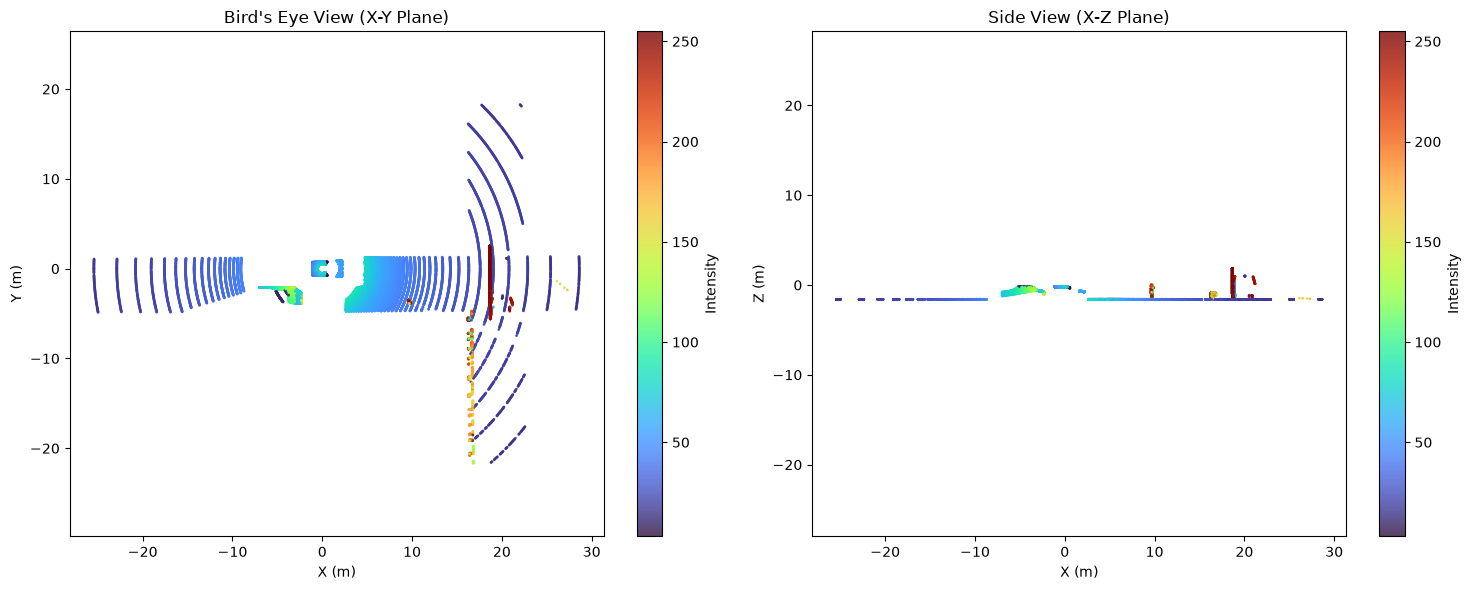

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bird's eye view (X-Y)
sc1 = ax1.scatter(plot_points[:, 0], plot_points[:, 1], s=1, c=plot_intensities, cmap='turbo', alpha=0.8)
ax1.set_title("Bird's Eye View (X-Y Plane)")
ax1.set_xlabel("X (m)")
ax1.set_ylabel("Y (m)")
ax1.axis('equal')
plt.colorbar(sc1, ax=ax1, label='Intensity')

# Side view (X-Z)
sc2 = ax2.scatter(plot_points[:, 0], plot_points[:, 2], s=1, c=plot_intensities, cmap='turbo', alpha=0.8)
ax2.set_title("Side View (X-Z Plane)")
ax2.set_xlabel("X (m)")
ax2.set_ylabel("Z (m)")
ax2.axis('equal')
plt.colorbar(sc2, ax=ax2, label='Intensity')

plt.tight_layout()
plt.show()


## 3D Visualization in Matplotlib
Let's project the points in an interactive 3D matplotlib plot.

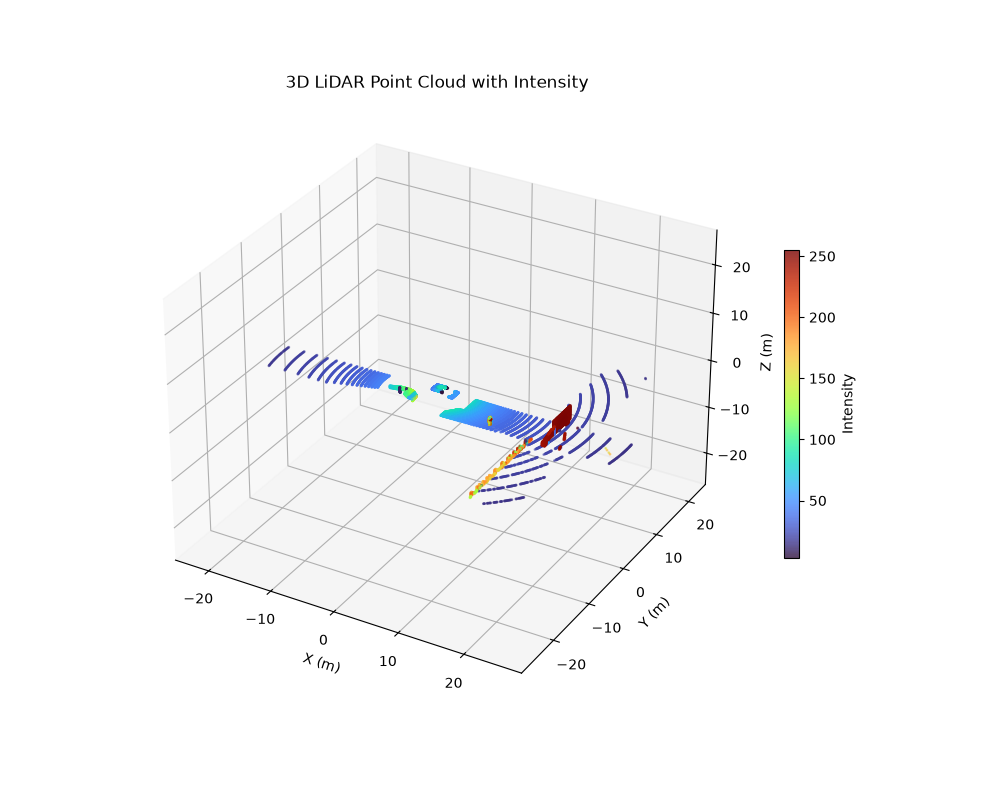

In [6]:
%matplotlib widget
# If %matplotlib widget does not work in your environment, use %matplotlib inline

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot 3D scatter
sc = ax.scatter(plot_points[:, 0], plot_points[:, 1], plot_points[:, 2],
                s=1, c=plot_intensities, cmap='turbo', alpha=0.8)

ax.set_title("3D LiDAR Point Cloud with Intensity")
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Z (m)")

# Set equal aspect ratio for realistic proportions
max_range = np.array([plot_points[:,0].max()-plot_points[:,0].min(), 
                      plot_points[:,1].max()-plot_points[:,1].min(), 
                      plot_points[:,2].max()-plot_points[:,2].min()]).max() / 2.0

mid_x = (plot_points[:,0].max()+plot_points[:,0].min()) * 0.5
mid_y = (plot_points[:,1].max()+plot_points[:,1].min()) * 0.5
mid_z = (plot_points[:,2].max()+plot_points[:,2].min()) * 0.5

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

fig.colorbar(sc, ax=ax, label='Intensity', shrink=0.5)
plt.show()


## Interactive 3D Visualization using Open3D
We can also visualize the points using Open3D's native interactive window. We map the intensity values to RGB colors for rendering.

In [7]:
# Normalize intensity to [0, 1] range for colormap mapping
intensity_norm = (intensities - intensities.min()) / (intensities.max() - intensities.min() + 1e-6)

# Get colors from matplotlib colormap (e.g., 'turbo')
cmap = plt.get_cmap('turbo')
colors = cmap(intensity_norm)[:, :3]  # Drop alpha channel

# Create an Open3D Legacy PointCloud for visualization
pcd_vis = o3d.geometry.PointCloud()
pcd_vis.points = o3d.utility.Vector3dVector(valid_points)
pcd_vis.colors = o3d.utility.Vector3dVector(colors)

# Note: this will open an external interactive window.
# Uncomment the line below to view the interactive plot:
o3d.visualization.draw_geometries([pcd_vis], window_name="LiDAR Point Cloud with Intensity", width=1024, height=768)
